# sciplex flow results

this notebook inspects one trained sciplex flow run from the hydra lightning runtime.

it supports:
- `fm`
- `ode`

it shows:
- total train and val loss
- train and val loss components
- held-out perturbation ranking by mean gene-wise w1 in the comparison space
- five-way distribution overlays for one selected held-out perturbation

note:
- the loss panel is in the model training space
- the distribution plots use a comparison space that strips projections from the evaluation space so decoded gene distributions stay interpretable


In [1]:
# %env PYTORCH_ENABLE_MPS_FALLBACK=1


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from flatcfm.analysis import (
    MetricSpaceSpec,
    build_flow_distribution_views,
    compute_flow_summary_metrics,
    evaluate_flow_predictions,
    get_or_build_flow_predictions,
    load_flow_run,
    reduce_group_metrics,
)

In [3]:
experiment_name = "sciplex_fm_deg_pca_d16_hpo"

run_dir = None
selected_perturbation = None
prediction_name = "held_out"
n_genes = 10
accelerator = None
w2_pca_n_components = 50
min_cells = 0


In [4]:
bundle = load_flow_run(run_dir=run_dir, experiment_name=experiment_name)
predictions = get_or_build_flow_predictions(bundle, prediction_name=prediction_name, accelerator=accelerator)
metrics_raw = compute_flow_summary_metrics(bundle, predictions, prediction_name=prediction_name)

per_perturbation = metrics_raw["per_perturbation"].copy()
if "n_cells" in per_perturbation.columns:
    per_perturbation = per_perturbation.loc[per_perturbation["n_cells"].fillna(0) >= int(min_cells)].copy()
per_perturbation = per_perturbation.reset_index(drop=True)

if selected_perturbation:
    perturbation = selected_perturbation
elif not per_perturbation.empty:
    perturbation = str(per_perturbation.iloc[0]["perturbation"])
else:
    raise ValueError(f"No heldout perturbations available with at least {min_cells} cells for this run")

metrics = dict(metrics_raw)
metrics["per_perturbation"] = per_perturbation

views = build_flow_distribution_views(
    bundle,
    predictions,
    perturbation=perturbation,
    prediction_name=prediction_name,
    sample_decode=metrics["sample_decode"],
)

prediction_metadata = predictions.uns.get("prediction_metadata", {})
summary = pd.DataFrame(
    [
        {
            "run_dir": str(bundle.run_dir),
            "experiment_name": str(bundle.cfg.experiment_name),
            "task_name": str(bundle.cfg.task.name),
            "model_family": str(bundle.cfg.model.get("family", "flow")),
            "train_space": str(bundle.metadata.get("space_mode", "")),
            "evaluation_space": str(bundle.metadata.get("evaluation_space_mode", "")),
            "comparison_space": str(metrics["comparison_space_label"]),
            "selected_perturbation": str(perturbation),
            "sample_decode": bool(metrics["sample_decode"]),
            "best_val_loss_train_space": float(metrics["best_val_loss"]),
            "mean_w2_squared_comparison_space": float(metrics["mean_w2_squared"]),
            "min_cells_filter": int(min_cells),
            "generated_predictions_in_memory": bool(predictions.uns.get("generated_in_memory", False)),
            "checkpoint_path": str(bundle.checkpoint_path) if bundle.checkpoint_path is not None else None,
        }
    ]
)
summary

/home/dac227/project_pi_sk2433/dac227/FlatCFM/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1811: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/dac227/project_pi_sk2433/dac227/FlatCFM/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1811: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/dac227/project_pi_sk2433/dac227/FlatCFM/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1811: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/dac227/project_pi_sk2433/dac227/FlatCFM/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1811: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/da

,run_dir,experiment_name,task_name,model_family,train_space,evaluation_space,comparison_space,selected_perturbation,sample_decode,best_val_loss_train_space,mean_w2_squared_comparison_space,min_cells_filter,generated_predictions_in_memory,checkpoint_path
0,/nfs/roberts/project/pi_sk2433/dac227/FlatCFM/...,sciplex_fm_deg_pca_d16_hpo,fm,flow,normalized_log1p -> pca,normalized_log1p -> pca,normalized_log1p,Danusertib (PHA-739358),False,10.0249,2111.469101,0,False,/nfs/roberts/scratch/pi_sk2433/dac227/FlatCFM/...


In [5]:
display(summary)

per_perturbation = metrics["per_perturbation"].copy()
per_perturbation


,run_dir,experiment_name,task_name,model_family,train_space,evaluation_space,comparison_space,selected_perturbation,sample_decode,best_val_loss_train_space,mean_w2_squared_comparison_space,min_cells_filter,generated_predictions_in_memory,checkpoint_path
0,/nfs/roberts/project/pi_sk2433/dac227/FlatCFM/...,sciplex_fm_deg_pca_d16_hpo,fm,flow,normalized_log1p -> pca,normalized_log1p -> pca,normalized_log1p,Danusertib (PHA-739358),False,10.0249,2111.469101,0,False,/nfs/roberts/scratch/pi_sk2433/dac227/FlatCFM/...


,perturbation,n_cells,mean_gene_w1,w2_squared
0,Danusertib (PHA-739358),100,0.256994,2173.450298
1,PHA-680632,101,0.254842,2102.772922
2,AMG-900,126,0.253826,1994.286180
3,Alvespimycin (17-DMAG) HCl,93,0.253457,2189.147561
4,Iniparib (BSI-201),131,0.253417,2145.761375
...,...,...,...,...
89,SRT3025 HCl,136,0.238603,2114.985102
90,M344,115,0.237412,2126.670781
91,UNC0379,135,0.236445,2127.775335
92,Trichostatin A (TSA),123,0.235188,2097.379385


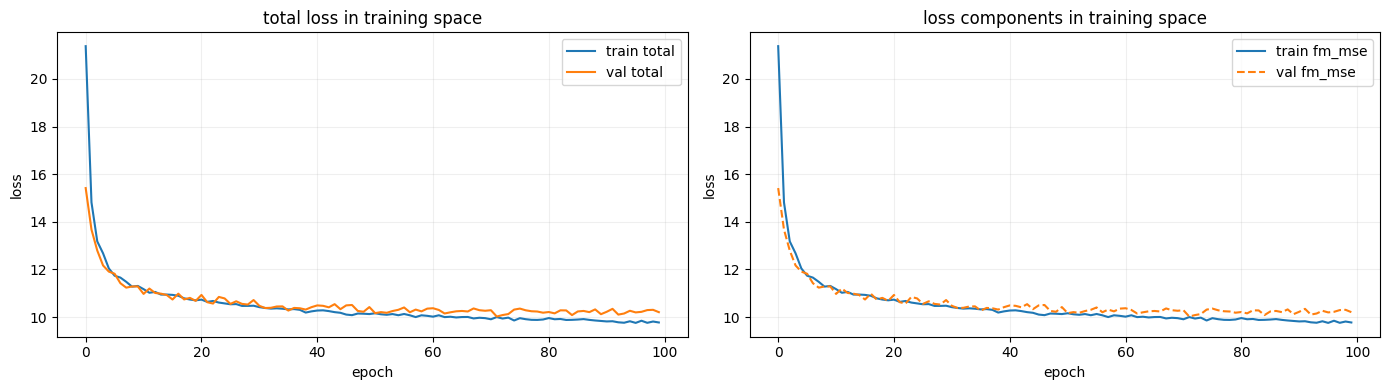

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(bundle.history.get("train_loss", []), label="train total")
axes[0].plot(bundle.history.get("val_loss", []), label="val total")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[0].set_title("total loss in training space")
axes[0].legend()
axes[0].grid(alpha=0.2)

for name, values in bundle.history.get("individual_train_losses", {}).items():
    axes[1].plot(values, label=f"train {name}")
for name, values in bundle.history.get("individual_val_losses", {}).items():
    axes[1].plot(values, linestyle="--", label=f"val {name}")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("loss")
axes[1].set_title("loss components in training space")
axes[1].legend()
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()


In [7]:
from flatcfm.data.space import transform_adata

gene_metrics = views["gene_metrics"].copy()

# compute mean expression from ALL K562 ground truth cells (control + perturbed)
# in the comparison space so gene ranking reflects real expression levels
_test_cell_type = str(bundle.cfg.splitter.test_cell_type)
_cell_type_col = str(bundle.datamodule.schema.sample_covariates[0].source_column)
_k562_mask = bundle.datamodule.adata_full.obs[_cell_type_col].astype(str) == _test_cell_type
_k562_raw = bundle.datamodule.adata_full[_k562_mask].copy()
_k562_comparison, _ = transform_adata(_k562_raw, bundle.comparison_pipeline, device="cpu")
_k562_X = np.asarray(_k562_comparison.X, dtype=np.float32)

# map by feature name (gene_metrics is sorted by w1, not feature order)
_mean_expr_map = dict(zip(views["feature_names"], _k562_X.mean(axis=0)))
gene_metrics["mean_expression"] = gene_metrics["feature"].map(_mean_expr_map).astype(float)
top_by_mean = gene_metrics.nlargest(n_genes, "mean_expression")

# also show top by w1 for reference
top_by_w1 = gene_metrics.nlargest(n_genes, "prediction_vs_observed_w1")

print(f"top {n_genes} genes by mean expression in all {_test_cell_type} cells ({_k562_X.shape[0]} cells):")
display(top_by_mean[["feature", "mean_expression", "prediction_vs_observed_w1"]])

print(f"\ntop {n_genes} genes by prediction vs observed w1 ({perturbation}):")
display(top_by_w1[["feature", "mean_expression", "prediction_vs_observed_w1"]])

display(per_perturbation.head(5))

# use top-by-mean for distribution plots
top_gene_metrics = top_by_mean

top 10 genes by mean expression in all K562 cells (25151 cells):


,feature,mean_expression,prediction_vs_observed_w1
2973,MT-RNR2,6.486124,0.192692
2873,MT-RNR1,4.899259,0.204799
2683,MT-ND5,3.701033,0.231824
937,MALAT1,3.694804,0.580463
2542,MT-ND4,3.240282,0.251874
1631,MT-CO1,3.178673,0.412988
996,NEAT1,2.555349,0.567343
363,SMYD3,2.540188,0.797935
1764,MT-ND2,2.468503,0.388949
1449,MT-ATP6,2.437907,0.452979



top 10 genes by prediction vs observed w1 (Danusertib (PHA-739358)):


,feature,mean_expression,prediction_vs_observed_w1
0,SLC25A37,0.978087,1.283036
1,LINC02506,0.776144,1.225707
2,PRKCB,2.159962,1.217416
3,HBG2,1.123788,1.176352
4,AL138720.1,0.839361,1.171596
5,BPTF,1.100860,1.121339
6,UBR5,1.040730,1.109797
7,HBG1,1.024795,1.106851
8,ST3GAL2,1.082807,1.086226
9,ST8SIA6,0.544145,1.076465


,perturbation,n_cells,mean_gene_w1,w2_squared
0,Danusertib (PHA-739358),100,0.256994,2173.450298
1,PHA-680632,101,0.254842,2102.772922
2,AMG-900,126,0.253826,1994.286180
3,Alvespimycin (17-DMAG) HCl,93,0.253457,2189.147561
4,Iniparib (BSI-201),131,0.253417,2145.761375


In [8]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

feature_to_idx = {name: idx for idx, name in enumerate(views["feature_names"])}
selected_features = top_gene_metrics["feature"].tolist()
plot_order = [
    ("control_observed", "control observed", "#444444"),
    ("control_decoded", "control round-trip decoded", "#CC6677"),
    ("perturbed_observed", "perturbed observed", "#228833"),
    ("perturbed_ground_truth_decoded", "perturbed gt round-trip decoded", "#AA4499"),
    ("perturbed_predicted_decoded", "perturbed predicted decoded", "#4477AA"),
]

n_rows = max(1, len(selected_features))
subplot_titles = []
for feature in selected_features:
    row_data = top_gene_metrics.loc[top_gene_metrics["feature"] == feature].iloc[0]
    mean_val = float(row_data["mean_expression"])
    w1_val = float(row_data["prediction_vs_observed_w1"])
    subplot_titles.append(f"{feature} | mean = {mean_val:.2f} | w1 = {w1_val:.4f}")

fig = make_subplots(rows=n_rows, cols=1, subplot_titles=subplot_titles)

for row, feature in enumerate(selected_features):
    idx = feature_to_idx[feature]
    values = [np.asarray(views[key][:, idx], dtype=np.float32) for key, _, _ in plot_order]
    mins = [float(item.min()) for item in values if item.size]
    maxs = [float(item.max()) for item in values if item.size]
    left = min(mins + [0.0]) if mins else 0.0
    right = max(maxs + [1.0]) if maxs else 1.0
    if np.isclose(left, right):
        right = left + 1.0
    bin_size = (right - left) / 50
    showlegend = row == 0

    for (key, label, color), arr in zip(plot_order, values):
        fig.add_trace(
            go.Histogram(
                x=arr,
                name=label,
                marker_color=color,
                opacity=0.4,
                histnorm="probability density",
                legendgroup=key,
                showlegend=showlegend,
                xbins=dict(start=left, end=right, size=bin_size),
            ),
            row=row + 1,
            col=1,
        )

fig.update_layout(
    barmode="overlay",
    height=300 * n_rows,
    width=950,
    title_text=f"top {n_genes} genes by mean expression — {views['comparison_space_label']}",
    legend=dict(x=1.01, y=1, xanchor="left"),
)
fig.update_yaxes(title_text="density")
fig.update_xaxes(title_text=f"value in {views['comparison_space_label']}", row=n_rows, col=1)
fig.show()

## interpretation

- `best_val_loss_train_space` is the best validation objective from flatcfm.training and is not directly comparable across different representation spaces
- `mean_w2_squared_comparison_space` is averaged across held-out perturbations in the comparison space used for decoded gene plots
- the selected perturbation defaults to the worst held-out perturbation by mean gene-wise w1 in the comparison space
- the distribution plots rank genes within that selected perturbation and do not average gene scores across perturbations


/home/dac227/project_pi_sk2433/dac227/FlatCFM/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1811: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/dac227/project_pi_sk2433/dac227/FlatCFM/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1811: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/dac227/project_pi_sk2433/dac227/FlatCFM/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1811: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/dac227/project_pi_sk2433/dac227/FlatCFM/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1811: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/da

,prediction_label,prediction_name,control_split,control_match,target_cell_type,min_cells,n_w2_groups,n_cosine_groups,mean_ref_logfc_norm
0,train K562 same control rule,train_same_control_rule,all_controls,test_cell_type,K562,0,94,94,5.603914
1,held-out,held_out,all_controls,test_cell_type,K562,0,94,94,5.129586


,prediction_label,prediction_name,metric_base,cell_weighted_mean,unweighted_mean
0,held-out,held_out,cosine_log_fc,0.309211,0.310631
2,train K562 same control rule,train_same_control_rule,cosine_log_fc,0.368501,0.375742
1,held-out,held_out,w2_squared,101.941358,103.495011
3,train K562 same control rule,train_same_control_rule,w2_squared,105.356186,107.327535


,model_name,cell_type,product_name,n_pred,n_ref,n_ctrl,aggregation,metric,metric_base,category,value,prediction_name,metric_space,metric_space_label,ref_logfc_norm,prediction_label,group_label
0,flatcfm,K562,(+)-JQ1,89,89,11096,none,w2_squared,w2_squared,cell_distribution,122.322245,train_same_control_rule,train_pca_50,normalized_log1p -> pca,3.110447,train K562 same control rule,K562 | (+)-JQ1
1,flatcfm,K562,2-Methoxyestradiol (2-MeOE2),80,80,11096,none,w2_squared,w2_squared,cell_distribution,103.017959,train_same_control_rule,train_pca_50,normalized_log1p -> pca,1.894590,train K562 same control rule,K562 | 2-Methoxyestradiol (2-MeOE2)
2,flatcfm,K562,A-366,130,130,11096,none,w2_squared,w2_squared,cell_distribution,107.554968,train_same_control_rule,train_pca_50,normalized_log1p -> pca,1.233338,train K562 same control rule,K562 | A-366
3,flatcfm,K562,ABT-737,136,136,11096,none,w2_squared,w2_squared,cell_distribution,97.376763,train_same_control_rule,train_pca_50,normalized_log1p -> pca,1.471969,train K562 same control rule,K562 | ABT-737
4,flatcfm,K562,AC480 (BMS-599626),141,141,11096,none,w2_squared,w2_squared,cell_distribution,96.278887,train_same_control_rule,train_pca_50,normalized_log1p -> pca,1.640912,train K562 same control rule,K562 | AC480 (BMS-599626)
5,flatcfm,K562,AG-14361,152,152,11096,none,w2_squared,w2_squared,cell_distribution,98.441578,train_same_control_rule,train_pca_50,normalized_log1p -> pca,1.292685,train K562 same control rule,K562 | AG-14361
6,flatcfm,K562,AICAR (Acadesine),118,118,11096,none,w2_squared,w2_squared,cell_distribution,111.150355,train_same_control_rule,train_pca_50,normalized_log1p -> pca,0.983036,train K562 same control rule,K562 | AICAR (Acadesine)
7,flatcfm,K562,AT9283,73,73,11096,none,w2_squared,w2_squared,cell_distribution,113.349126,train_same_control_rule,train_pca_50,normalized_log1p -> pca,4.628113,train K562 same control rule,K562 | AT9283
8,flatcfm,K562,Abexinostat (PCI-24781),86,86,11096,none,w2_squared,w2_squared,cell_distribution,116.925786,train_same_control_rule,train_pca_50,normalized_log1p -> pca,5.003312,train K562 same control rule,K562 | Abexinostat (PCI-24781)
9,flatcfm,K562,Alisertib (MLN8237),99,99,11096,none,w2_squared,w2_squared,cell_distribution,120.918559,train_same_control_rule,train_pca_50,normalized_log1p -> pca,3.792588,train K562 same control rule,K562 | Alisertib (MLN8237)


,model_name,cell_type,product_name,n_pred,n_ref,n_ctrl,aggregation,metric,metric_base,category,value,prediction_name,metric_space,metric_space_label,ref_logfc_norm,prediction_label,group_label
0,flatcfm,K562,AG-490 (Tyrphostin B42),164,164,12225,none,w2_squared,w2_squared,cell_distribution,98.829898,held_out,train_pca_50,normalized_log1p -> pca,1.740471,held-out,K562 | AG-490 (Tyrphostin B42)
1,flatcfm,K562,AMG-900,126,126,12225,none,w2_squared,w2_squared,cell_distribution,105.925917,held_out,train_pca_50,normalized_log1p -> pca,4.405731,held-out,K562 | AMG-900
2,flatcfm,K562,AR-42,99,99,12225,none,w2_squared,w2_squared,cell_distribution,110.202296,held_out,train_pca_50,normalized_log1p -> pca,4.696393,held-out,K562 | AR-42
3,flatcfm,K562,AZ 960,115,115,12225,none,w2_squared,w2_squared,cell_distribution,113.473982,held_out,train_pca_50,normalized_log1p -> pca,1.972525,held-out,K562 | AZ 960
4,flatcfm,K562,AZD1480,129,129,12225,none,w2_squared,w2_squared,cell_distribution,89.369025,held_out,train_pca_50,normalized_log1p -> pca,1.702364,held-out,K562 | AZD1480
5,flatcfm,K562,Alendronate sodium trihydrate,149,149,12225,none,w2_squared,w2_squared,cell_distribution,100.184464,held_out,train_pca_50,normalized_log1p -> pca,1.331996,held-out,K562 | Alendronate sodium trihydrate
6,flatcfm,K562,Alvespimycin (17-DMAG) HCl,93,93,12225,none,w2_squared,w2_squared,cell_distribution,135.826123,held_out,train_pca_50,normalized_log1p -> pca,4.004182,held-out,K562 | Alvespimycin (17-DMAG) HCl
7,flatcfm,K562,Anacardic Acid,133,133,12225,none,w2_squared,w2_squared,cell_distribution,100.176901,held_out,train_pca_50,normalized_log1p -> pca,0.930603,held-out,K562 | Anacardic Acid
8,flatcfm,K562,Andarine,163,163,12225,none,w2_squared,w2_squared,cell_distribution,99.265754,held_out,train_pca_50,normalized_log1p -> pca,1.217666,held-out,K562 | Andarine
9,flatcfm,K562,Aurora A Inhibitor I,138,138,12225,none,w2_squared,w2_squared,cell_distribution,97.682820,held_out,train_pca_50,normalized_log1p -> pca,1.259481,held-out,K562 | Aurora A Inhibitor I


,model_name,cell_type,product_name,n_pred,n_ref,n_ctrl,aggregation,metric,metric_base,category,value,prediction_name,metric_space,metric_space_label,ref_logfc_norm,prediction_label,group_label
0,flatcfm,K562,(+)-JQ1,89,89,11096,logfc,cosine_log_fc,cosine_log_fc,profile,0.164947,train_same_control_rule,train_base,normalized_log1p,6.850606,train K562 same control rule,K562 | (+)-JQ1
1,flatcfm,K562,2-Methoxyestradiol (2-MeOE2),80,80,11096,logfc,cosine_log_fc,cosine_log_fc,profile,0.293792,train_same_control_rule,train_base,normalized_log1p,5.867160,train K562 same control rule,K562 | 2-Methoxyestradiol (2-MeOE2)
2,flatcfm,K562,A-366,130,130,11096,logfc,cosine_log_fc,cosine_log_fc,profile,0.244034,train_same_control_rule,train_base,normalized_log1p,4.529300,train K562 same control rule,K562 | A-366
3,flatcfm,K562,ABT-737,136,136,11096,logfc,cosine_log_fc,cosine_log_fc,profile,0.441325,train_same_control_rule,train_base,normalized_log1p,4.618642,train K562 same control rule,K562 | ABT-737
4,flatcfm,K562,AC480 (BMS-599626),141,141,11096,logfc,cosine_log_fc,cosine_log_fc,profile,0.434318,train_same_control_rule,train_base,normalized_log1p,4.540314,train K562 same control rule,K562 | AC480 (BMS-599626)
5,flatcfm,K562,AG-14361,152,152,11096,logfc,cosine_log_fc,cosine_log_fc,profile,0.289221,train_same_control_rule,train_base,normalized_log1p,4.306196,train K562 same control rule,K562 | AG-14361
6,flatcfm,K562,AICAR (Acadesine),118,118,11096,logfc,cosine_log_fc,cosine_log_fc,profile,0.218178,train_same_control_rule,train_base,normalized_log1p,4.739433,train K562 same control rule,K562 | AICAR (Acadesine)
7,flatcfm,K562,AT9283,73,73,11096,logfc,cosine_log_fc,cosine_log_fc,profile,0.562495,train_same_control_rule,train_base,normalized_log1p,7.667733,train K562 same control rule,K562 | AT9283
8,flatcfm,K562,Abexinostat (PCI-24781),86,86,11096,logfc,cosine_log_fc,cosine_log_fc,profile,0.538260,train_same_control_rule,train_base,normalized_log1p,8.194654,train K562 same control rule,K562 | Abexinostat (PCI-24781)
9,flatcfm,K562,Alisertib (MLN8237),99,99,11096,logfc,cosine_log_fc,cosine_log_fc,profile,0.585372,train_same_control_rule,train_base,normalized_log1p,6.269399,train K562 same control rule,K562 | Alisertib (MLN8237)


,model_name,cell_type,product_name,n_pred,n_ref,n_ctrl,aggregation,metric,metric_base,category,value,prediction_name,metric_space,metric_space_label,ref_logfc_norm,prediction_label,group_label
0,flatcfm,K562,AG-490 (Tyrphostin B42),164,164,12225,logfc,cosine_log_fc,cosine_log_fc,profile,0.290982,held_out,train_base,normalized_log1p,4.414380,held-out,K562 | AG-490 (Tyrphostin B42)
1,flatcfm,K562,AMG-900,126,126,12225,logfc,cosine_log_fc,cosine_log_fc,profile,0.707517,held_out,train_base,normalized_log1p,6.340759,held-out,K562 | AMG-900
2,flatcfm,K562,AR-42,99,99,12225,logfc,cosine_log_fc,cosine_log_fc,profile,0.612388,held_out,train_base,normalized_log1p,7.493540,held-out,K562 | AR-42
3,flatcfm,K562,AZ 960,115,115,12225,logfc,cosine_log_fc,cosine_log_fc,profile,0.347686,held_out,train_base,normalized_log1p,5.135537,held-out,K562 | AZ 960
4,flatcfm,K562,AZD1480,129,129,12225,logfc,cosine_log_fc,cosine_log_fc,profile,0.475269,held_out,train_base,normalized_log1p,4.819079,held-out,K562 | AZD1480
5,flatcfm,K562,Alendronate sodium trihydrate,149,149,12225,logfc,cosine_log_fc,cosine_log_fc,profile,0.267950,held_out,train_base,normalized_log1p,4.351751,held-out,K562 | Alendronate sodium trihydrate
6,flatcfm,K562,Alvespimycin (17-DMAG) HCl,93,93,12225,logfc,cosine_log_fc,cosine_log_fc,profile,0.093176,held_out,train_base,normalized_log1p,7.580155,held-out,K562 | Alvespimycin (17-DMAG) HCl
7,flatcfm,K562,Anacardic Acid,133,133,12225,logfc,cosine_log_fc,cosine_log_fc,profile,0.180500,held_out,train_base,normalized_log1p,4.378304,held-out,K562 | Anacardic Acid
8,flatcfm,K562,Andarine,163,163,12225,logfc,cosine_log_fc,cosine_log_fc,profile,0.393860,held_out,train_base,normalized_log1p,4.322372,held-out,K562 | Andarine
9,flatcfm,K562,Aurora A Inhibitor I,138,138,12225,logfc,cosine_log_fc,cosine_log_fc,profile,0.334146,held_out,train_base,normalized_log1p,4.466421,held-out,K562 | Aurora A Inhibitor I


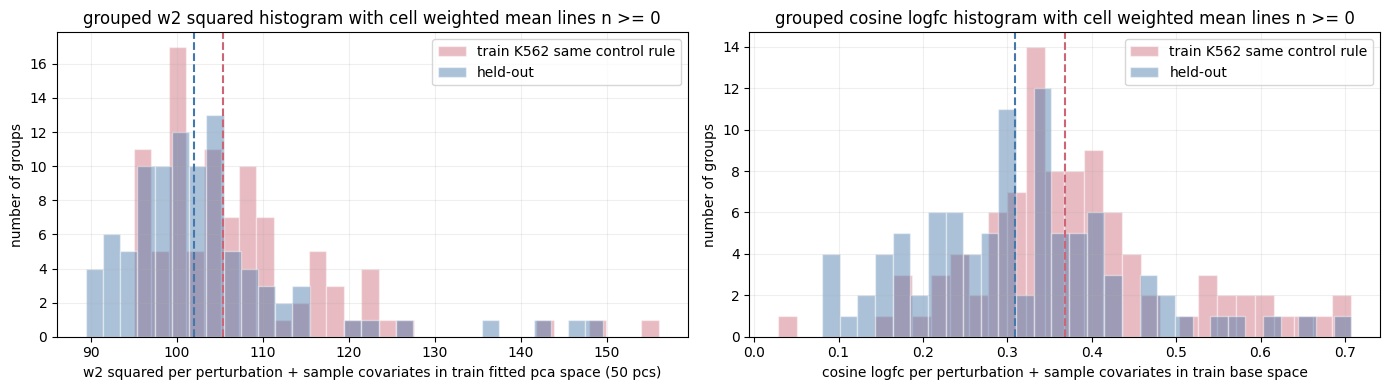

In [9]:
import gc

min_ref_logfc_norm = 0.0

held_out_control_source = {
    "split": str(bundle.datamodule.predict_spec["control_source"]["split"]),
    "match_cell_types_from": str(bundle.datamodule.predict_spec["control_source"]["match_cell_types_from"]),
}

test_cell_type = str(bundle.cfg.splitter.test_cell_type)
train_prediction_name = "train_same_control_rule"
train_prediction_overrides = {
    "split": "train",
    "target_subset": "perturbed",
    "target_filters": {"obs_equals": {"cell_type": test_cell_type}, "obs_in": {}},
    "control_source": held_out_control_source,
}
train_predictions = get_or_build_flow_predictions(
    bundle,
    prediction_name=train_prediction_name,
    prediction_overrides=train_prediction_overrides,
    accelerator=accelerator,
)

group_columns = (
    *(field.source_column for field in bundle.datamodule.schema.sample_covariates),
    bundle.datamodule.schema.perturbation_source,
)
prediction_labels = {
    train_prediction_name: f"train {test_cell_type} same control rule",
    prediction_name: "held-out",
}

w2_metric_space = MetricSpaceSpec(
    name=f"train_pca_{w2_pca_n_components}",
    kind="train_pca",
    pca_n_components=int(w2_pca_n_components),
    fit_split="train",
)
base_metric_space = MetricSpaceSpec(name="train_base", kind="train_base", fit_split="train")

# evaluate one at a time to avoid OOM
eval_specs = [
    (predictions, prediction_name, w2_metric_space, ("w2_squared",)),
    (train_predictions, train_prediction_name, w2_metric_space, ("w2_squared",)),
    (predictions, prediction_name, base_metric_space, ("cosine_log_fc",)),
    (train_predictions, train_prediction_name, base_metric_space, ("cosine_log_fc",)),
]
eval_results = {}
for pred_adata, pred_name, mspace, mnames in eval_specs:
    result = evaluate_flow_predictions(
        bundle,
        pred_adata,
        metric_space=mspace,
        metrics=mnames,
        prediction_name=pred_name,
        group_columns=tuple(group_columns),
        reductions=("unweighted_mean", "cell_weighted_mean"),
        include_logfc_norms=True,
        min_cells=int(min_cells),
    )
    pg = result["per_group"].copy()
    summary = result["summary"].copy()
    del result
    gc.collect()
    if not pg.empty:
        pg["prediction_label"] = prediction_labels.get(pred_name, pred_name)
        if group_columns:
            pg["group_label"] = pg[list(group_columns)].astype(str).agg(" | ".join, axis=1)
    eval_results[(pred_name, mnames[0])] = {"per_group": pg, "summary": summary}

val_w2_groups = eval_results[(prediction_name, "w2_squared")]["per_group"]
train_w2_groups = eval_results[(train_prediction_name, "w2_squared")]["per_group"]
val_cosine_groups = eval_results[(prediction_name, "cosine_log_fc")]["per_group"]
train_cosine_groups = eval_results[(train_prediction_name, "cosine_log_fc")]["per_group"]


def filter_small_effect(frame):
    if frame.empty or "ref_logfc_norm" not in frame.columns or min_ref_logfc_norm <= 0:
        return frame.copy()
    return frame.loc[frame["ref_logfc_norm"].fillna(0.0) >= float(min_ref_logfc_norm)].copy()


val_cosine_filtered = filter_small_effect(val_cosine_groups)
train_cosine_filtered = filter_small_effect(train_cosine_groups)

# build summary table
summary_rows = pd.concat(
    [r["summary"] for r in eval_results.values() if not r["summary"].empty],
    ignore_index=True,
)
if not summary_rows.empty:
    summary_rows["prediction_label"] = summary_rows["prediction_name"].map(prediction_labels)
summary_display = pd.DataFrame()
if not summary_rows.empty:
    summary_display = (
        summary_rows.pivot_table(
            index=["prediction_label", "prediction_name", "metric_base"],
            columns="reduction",
            values="value",
            aggfunc="first",
        )
        .reset_index()
        .sort_values(["metric_base", "prediction_label"])
    )
    summary_display.columns.name = None

# filtered cosine summary
filtered_cosine_summary = pd.concat(
    [
        reduce_group_metrics(train_cosine_filtered, reductions=("unweighted_mean", "cell_weighted_mean")),
        reduce_group_metrics(val_cosine_filtered, reductions=("unweighted_mean", "cell_weighted_mean")),
    ],
    ignore_index=True,
)
if not filtered_cosine_summary.empty:
    filtered_cosine_summary["prediction_label"] = filtered_cosine_summary["prediction_name"].map(prediction_labels)
filtered_cosine_display = pd.DataFrame()
if not filtered_cosine_summary.empty:
    filtered_cosine_display = (
        filtered_cosine_summary.pivot_table(
            index=["prediction_label", "prediction_name", "metric_base"],
            columns="reduction",
            values="value",
            aggfunc="first",
        )
        .reset_index()
        .sort_values(["metric_base", "prediction_label"])
    )
    filtered_cosine_display.columns.name = None

# slice summary
slice_summary = pd.DataFrame(
    [
        {
            "prediction_label": prediction_labels[train_prediction_name],
            "prediction_name": train_prediction_name,
            "control_split": held_out_control_source["split"],
            "control_match": held_out_control_source["match_cell_types_from"],
            "target_cell_type": test_cell_type,
            "min_cells": int(min_cells),
            "n_w2_groups": int((train_w2_groups["metric_base"] == "w2_squared").sum())
            if not train_w2_groups.empty
            else 0,
            "n_cosine_groups": int((train_cosine_groups["metric_base"] == "cosine_log_fc").sum())
            if not train_cosine_groups.empty
            else 0,
            "mean_ref_logfc_norm": float(train_cosine_groups["ref_logfc_norm"].dropna().mean())
            if not train_cosine_groups.empty
            else float("nan"),
        },
        {
            "prediction_label": prediction_labels[prediction_name],
            "prediction_name": prediction_name,
            "control_split": held_out_control_source["split"],
            "control_match": held_out_control_source["match_cell_types_from"],
            "target_cell_type": test_cell_type,
            "min_cells": int(min_cells),
            "n_w2_groups": int((val_w2_groups["metric_base"] == "w2_squared").sum()) if not val_w2_groups.empty else 0,
            "n_cosine_groups": int((val_cosine_groups["metric_base"] == "cosine_log_fc").sum())
            if not val_cosine_groups.empty
            else 0,
            "mean_ref_logfc_norm": float(val_cosine_groups["ref_logfc_norm"].dropna().mean())
            if not val_cosine_groups.empty
            else float("nan"),
        },
    ]
)

display(slice_summary)
display(summary_display)
if min_ref_logfc_norm > 0:
    display(filtered_cosine_display)

display(train_w2_groups.head(10))
display(val_w2_groups.head(10))
display(train_cosine_groups.head(10))
display(val_cosine_groups.head(10))


def weighted_metric_mean(frame, metric_base):
    subset = frame.loc[
        (frame["metric_base"] == metric_base) & frame["value"].notna() & frame["n_ref"].notna() & (frame["n_ref"] > 0)
    ]
    if subset.empty:
        return float("nan")
    return float(np.average(subset["value"].to_numpy(), weights=subset["n_ref"].to_numpy()))


cosine_for_plot = {train_prediction_name: train_cosine_filtered, prediction_name: val_cosine_filtered}

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
bins = 30

axes[0].hist(
    train_w2_groups.loc[train_w2_groups["metric_base"] == "w2_squared", "value"].dropna(),
    bins=bins,
    alpha=0.45,
    color="#CC6677",
    edgecolor="white",
    label=prediction_labels[train_prediction_name],
)
axes[0].hist(
    val_w2_groups.loc[val_w2_groups["metric_base"] == "w2_squared", "value"].dropna(),
    bins=bins,
    alpha=0.45,
    color="#4477AA",
    edgecolor="white",
    label=prediction_labels[prediction_name],
)
axes[0].axvline(weighted_metric_mean(train_w2_groups, "w2_squared"), color="#CC6677", linestyle="--")
axes[0].axvline(weighted_metric_mean(val_w2_groups, "w2_squared"), color="#4477AA", linestyle="--")
axes[0].set_xlabel(
    f"w2 squared per perturbation + sample covariates in train fitted pca space ({w2_pca_n_components} pcs)"
)
axes[0].set_ylabel("number of groups")
axes[0].set_title(f"grouped w2 squared histogram with cell weighted mean lines n >= {int(min_cells)}")
axes[0].legend()
axes[0].grid(alpha=0.2)

axes[1].hist(
    cosine_for_plot[train_prediction_name]
    .loc[cosine_for_plot[train_prediction_name]["metric_base"] == "cosine_log_fc", "value"]
    .dropna(),
    bins=bins,
    alpha=0.45,
    color="#CC6677",
    edgecolor="white",
    label=prediction_labels[train_prediction_name],
)
axes[1].hist(
    cosine_for_plot[prediction_name]
    .loc[cosine_for_plot[prediction_name]["metric_base"] == "cosine_log_fc", "value"]
    .dropna(),
    bins=bins,
    alpha=0.45,
    color="#4477AA",
    edgecolor="white",
    label=prediction_labels[prediction_name],
)
axes[1].axvline(
    weighted_metric_mean(cosine_for_plot[train_prediction_name], "cosine_log_fc"), color="#CC6677", linestyle="--"
)
axes[1].axvline(
    weighted_metric_mean(cosine_for_plot[prediction_name], "cosine_log_fc"), color="#4477AA", linestyle="--"
)
axes[1].set_xlabel("cosine logfc per perturbation + sample covariates in train base space")
axes[1].set_ylabel("number of groups")
axes[1].set_title(f"grouped cosine logfc histogram with cell weighted mean lines n >= {int(min_cells)}")
if min_ref_logfc_norm > 0:
    axes[1].set_title(
        f"grouped cosine logfc histogram with cell weighted mean lines\nfiltered to ref logfc norm >= {min_ref_logfc_norm:g} and n >= {int(min_cells)}"
    )
axes[1].legend()
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

/tmp/ipykernel_1400279/2815655668.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for grp_key, frame in obs.groupby(list(group_columns)):


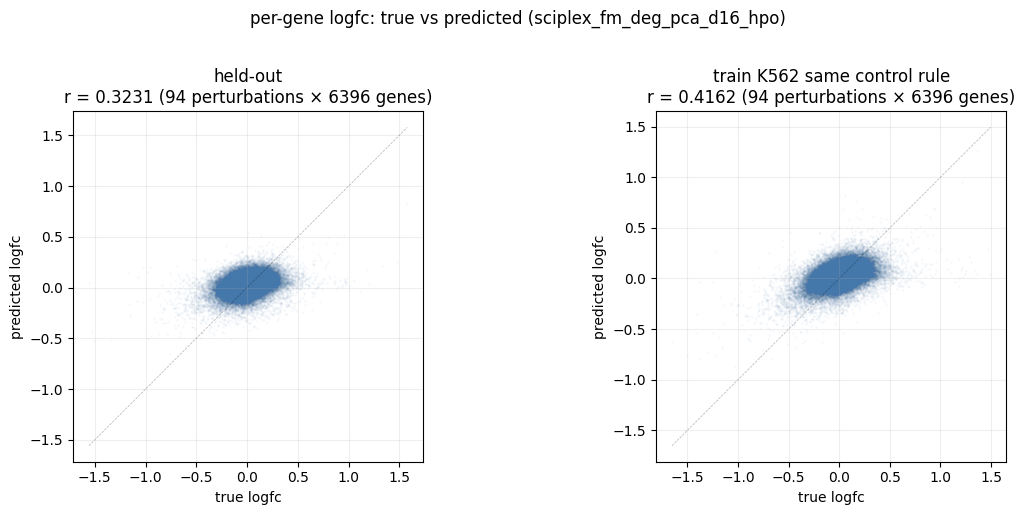

In [10]:
from flatcfm.analysis.benchmarks import prepare_metric_space_views
from scipy.stats import pearsonr

perturbation_col = bundle.datamodule.schema.perturbation_source
control_value = str(bundle.datamodule.schema.control_value)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

split_specs = [
    (predictions, prediction_name),
    (train_predictions, train_prediction_name),
]

for ax, (pred_adata, pred_name) in zip(axes, split_specs):
    lfc_views = prepare_metric_space_views(
        datamodule=bundle.datamodule,
        raw_adata=bundle.datamodule.adata_full,
        predictions=pred_adata,
        metric_space=base_metric_space,
        comparison_pipeline=bundle.comparison_pipeline,
        comparison_space_cfg=bundle.comparison_space_cfg,
        cache=bundle.cache,
    )

    pred_X = np.asarray(lfc_views.prediction_adata.X, dtype=np.float64)
    ref_X = np.asarray(lfc_views.reference_adata.X, dtype=np.float64)
    ctrl_X = np.asarray(lfc_views.control_adata.X, dtype=np.float64)
    obs = lfc_views.obs

    ctrl_mean = ctrl_X.mean(axis=0)

    true_lfcs = []
    pred_lfcs = []
    for grp_key, frame in obs.groupby(list(group_columns)):
        if not isinstance(grp_key, tuple):
            grp_key = (grp_key,)
        if str(grp_key[-1]) == control_value:
            continue
        idx = frame.index.to_numpy()
        true_lfcs.append(ref_X[idx].mean(axis=0) - ctrl_mean)
        pred_lfcs.append(pred_X[idx].mean(axis=0) - ctrl_mean)

    true_flat = np.concatenate(true_lfcs)
    pred_flat = np.concatenate(pred_lfcs)

    r, _ = pearsonr(true_flat, pred_flat)
    n_perts = len(true_lfcs)
    n_genes = pred_X.shape[1]

    ax.scatter(true_flat, pred_flat, alpha=0.03, s=1, color="#4477AA", rasterized=True)
    lo = min(true_flat.min(), pred_flat.min())
    hi = max(true_flat.max(), pred_flat.max())
    ax.plot([lo, hi], [lo, hi], "k--", alpha=0.3, linewidth=0.5)
    ax.set_xlabel("true logfc")
    ax.set_ylabel("predicted logfc")
    ax.set_title(f"{prediction_labels[pred_name]}\nr = {r:.4f} ({n_perts} perturbations \u00d7 {n_genes} genes)")
    ax.set_aspect("equal")
    ax.grid(alpha=0.2)

plt.suptitle(f"per-gene logfc: true vs predicted ({experiment_name})", y=1.02)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1400279/3191580477.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for grp_key, frame in obs.groupby(list(group_columns)):


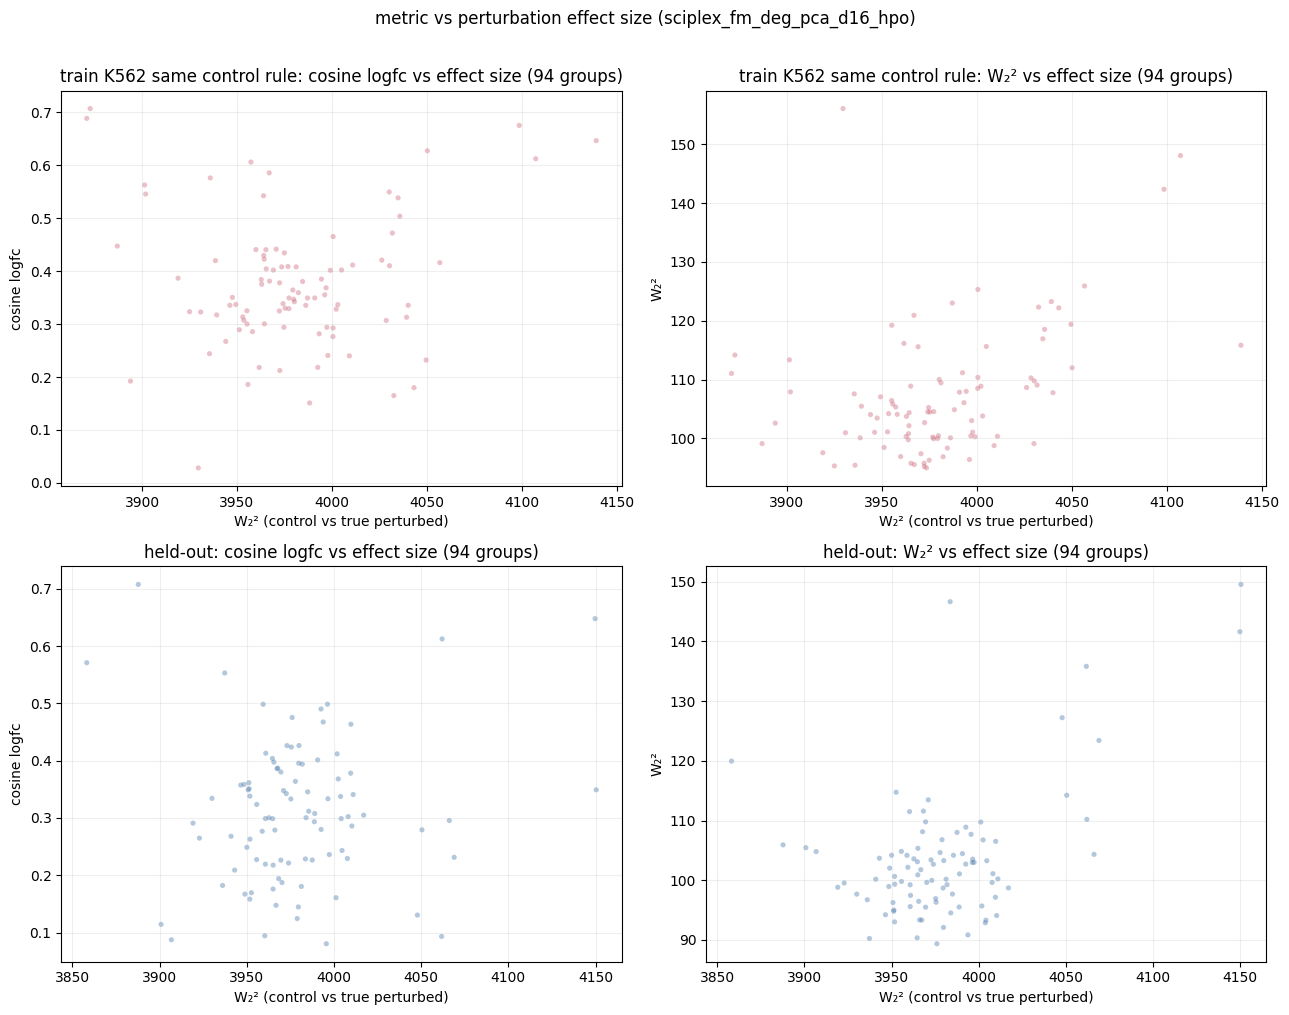

In [11]:
# cosine logfc and w2 vs control-vs-perturbed W2 per group
# x axis = ground truth distributional shift (how hard the prediction task is)

from flatcfm.analysis.benchmarks.metrics import compute_w2_squared


def _compute_ctrl_vs_perturbed_w2(pred_adata, metric_space):
    """compute W2 squared between control and true perturbed per group"""

    views = prepare_metric_space_views(
        datamodule=bundle.datamodule,
        raw_adata=bundle.datamodule.adata_full,
        predictions=pred_adata,
        metric_space=metric_space,
        comparison_pipeline=bundle.comparison_pipeline,
        comparison_space_cfg=bundle.comparison_space_cfg,
        cache=bundle.cache,
    )
    ref_X = np.asarray(views.reference_adata.X, dtype=np.float64)
    ctrl_X = np.asarray(views.control_adata.X, dtype=np.float64)
    obs = views.obs

    records = {}
    for grp_key, frame in obs.groupby(list(group_columns)):
        if not isinstance(grp_key, tuple):
            grp_key = (grp_key,)
        if str(grp_key[-1]) == control_value:
            continue
        label = " | ".join(str(k) for k in grp_key)
        idx = frame.index.to_numpy()
        ref_grp = ref_X[idx]
        if ref_grp.shape[0] < 5:
            continue
        records[label] = compute_w2_squared(ref_grp, ctrl_X, max_samples=2000)
    return pd.DataFrame({"group_label": list(records.keys()), "ctrl_w2": list(records.values())})


perturbation_col = bundle.datamodule.schema.perturbation_source
control_value = str(bundle.datamodule.schema.control_value)

train_ctrl_w2_df = _compute_ctrl_vs_perturbed_w2(train_predictions, base_metric_space)
val_ctrl_w2_df = _compute_ctrl_vs_perturbed_w2(predictions, base_metric_space)


def _merge_with_ctrl_w2(pg, metric_base, ctrl_w2_df):
    subset = pg.loc[pg["metric_base"] == metric_base, ["group_label", "value"]].dropna()
    return subset.merge(ctrl_w2_df, on="group_label", how="inner")


fig, axes = plt.subplots(2, 2, figsize=(13, 10))

for col_idx, (metric_base, metric_label) in enumerate([("cosine_log_fc", "cosine logfc"), ("w2_squared", "W₂²")]):
    for row_idx, (pg, ctrl_w2_df, split_label, color) in enumerate(
        [
            (
                train_cosine_groups if metric_base == "cosine_log_fc" else train_w2_groups,
                train_ctrl_w2_df,
                prediction_labels[train_prediction_name],
                "#CC6677",
            ),
            (
                val_cosine_groups if metric_base == "cosine_log_fc" else val_w2_groups,
                val_ctrl_w2_df,
                prediction_labels[prediction_name],
                "#4477AA",
            ),
        ]
    ):
        ax = axes[row_idx, col_idx]
        merged = _merge_with_ctrl_w2(pg, metric_base, ctrl_w2_df)
        if merged.empty:
            ax.text(0.5, 0.5, "no data", transform=ax.transAxes, ha="center")
            continue
        ax.scatter(merged["ctrl_w2"], merged["value"], alpha=0.4, s=14, color=color, edgecolors="none")
        ax.set_xlabel("W₂² (control vs true perturbed)")
        ax.set_ylabel(metric_label)
        ax.set_title(f"{split_label}: {metric_label} vs effect size ({len(merged)} groups)")
        ax.grid(alpha=0.2)

plt.suptitle(f"metric vs perturbation effect size ({experiment_name})", y=1.01)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1400279/1002922010.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for grp_key, frame in obs.groupby(list(group_columns)):


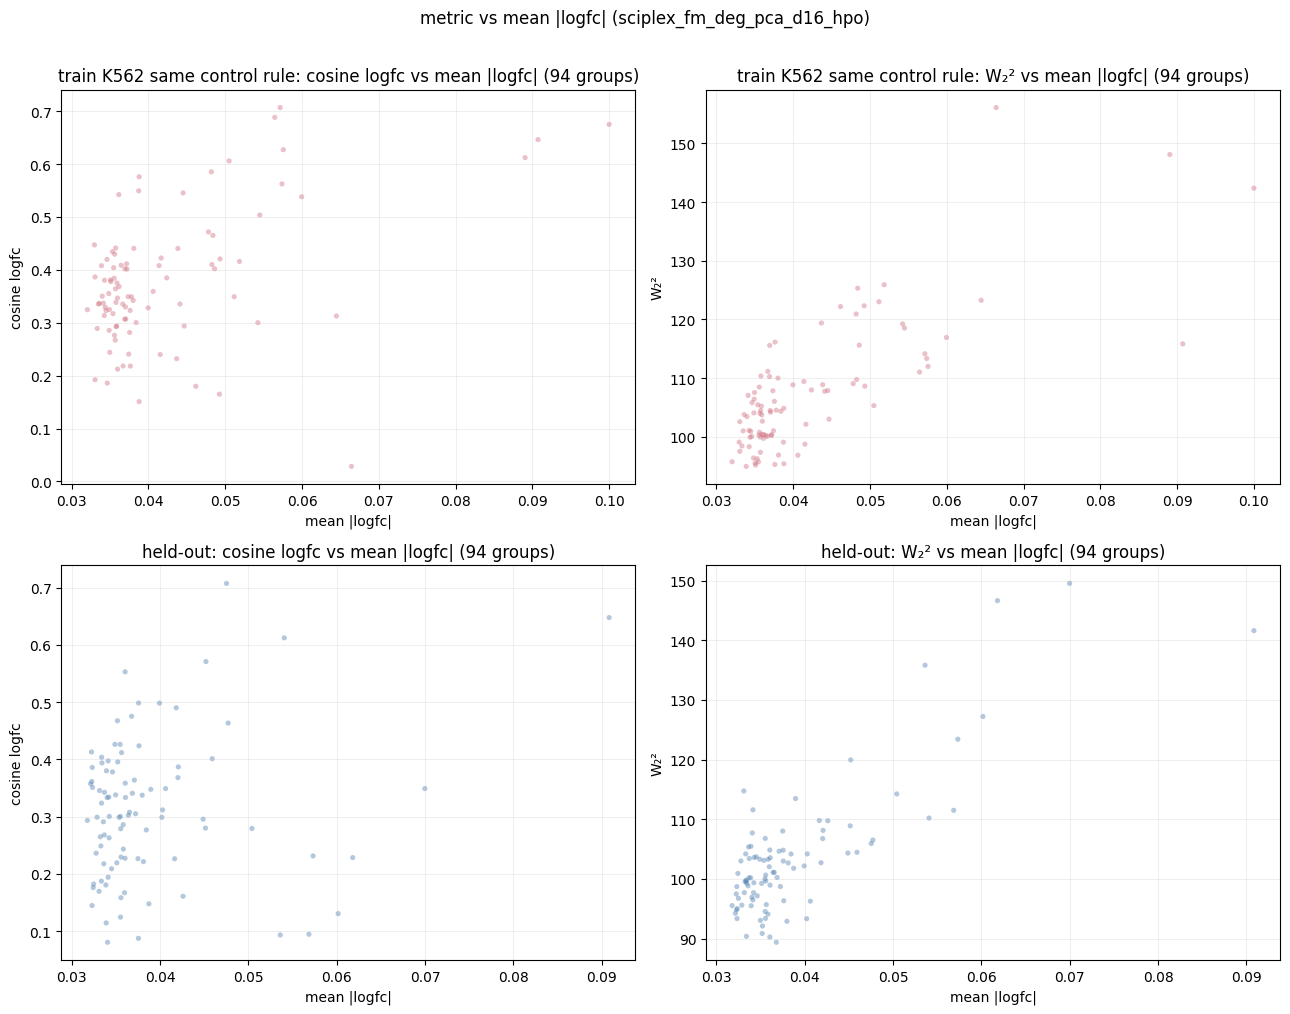

In [12]:
# same plots but with mean |logfc| on x axis


def _compute_mean_logfc(pred_adata, metric_space):
    """compute mean absolute logfc per group from reference vs control"""

    views = prepare_metric_space_views(
        datamodule=bundle.datamodule,
        raw_adata=bundle.datamodule.adata_full,
        predictions=pred_adata,
        metric_space=metric_space,
        comparison_pipeline=bundle.comparison_pipeline,
        comparison_space_cfg=bundle.comparison_space_cfg,
        cache=bundle.cache,
    )
    ref_X = np.asarray(views.reference_adata.X, dtype=np.float64)
    ctrl_X = np.asarray(views.control_adata.X, dtype=np.float64)
    obs = views.obs
    ctrl_mean = ctrl_X.mean(axis=0)

    records = {}
    for grp_key, frame in obs.groupby(list(group_columns)):
        if not isinstance(grp_key, tuple):
            grp_key = (grp_key,)
        if str(grp_key[-1]) == control_value:
            continue
        label = " | ".join(str(k) for k in grp_key)
        idx = frame.index.to_numpy()
        ref_grp = ref_X[idx]
        if ref_grp.shape[0] < 5:
            continue
        lfc = ref_grp.mean(axis=0) - ctrl_mean
        records[label] = float(np.mean(np.abs(lfc)))
    return pd.DataFrame({"group_label": list(records.keys()), "mean_abs_logfc": list(records.values())})


train_logfc_df = _compute_mean_logfc(train_predictions, base_metric_space)
val_logfc_df = _compute_mean_logfc(predictions, base_metric_space)


def _merge_with_logfc(pg, metric_base, logfc_df):
    subset = pg.loc[pg["metric_base"] == metric_base, ["group_label", "value"]].dropna()
    return subset.merge(logfc_df, on="group_label", how="inner")


fig, axes = plt.subplots(2, 2, figsize=(13, 10))

for col_idx, (metric_base, metric_label) in enumerate([("cosine_log_fc", "cosine logfc"), ("w2_squared", "W₂²")]):
    for row_idx, (pg, logfc_df, split_label, color) in enumerate(
        [
            (
                train_cosine_groups if metric_base == "cosine_log_fc" else train_w2_groups,
                train_logfc_df,
                prediction_labels[train_prediction_name],
                "#CC6677",
            ),
            (
                val_cosine_groups if metric_base == "cosine_log_fc" else val_w2_groups,
                val_logfc_df,
                prediction_labels[prediction_name],
                "#4477AA",
            ),
        ]
    ):
        ax = axes[row_idx, col_idx]
        merged = _merge_with_logfc(pg, metric_base, logfc_df)
        if merged.empty:
            ax.text(0.5, 0.5, "no data", transform=ax.transAxes, ha="center")
            continue
        ax.scatter(merged["mean_abs_logfc"], merged["value"], alpha=0.4, s=14, color=color, edgecolors="none")
        ax.set_xlabel("mean |logfc|")
        ax.set_ylabel(metric_label)
        ax.set_title(f"{split_label}: {metric_label} vs mean |logfc| ({len(merged)} groups)")
        ax.grid(alpha=0.2)

plt.suptitle(f"metric vs mean |logfc| ({experiment_name})", y=1.01)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1400279/806310865.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for grp_key, frame in ho_obs.groupby(list(group_columns)):


                            label  mean_abs_pred_lfc  mean_abs_true_lfc
              Dacinostat (LAQ824)           0.040197           0.090854
                        Dasatinib           0.021009           0.069985
Patupilone (EPO906, Epothilone B)           0.021081           0.061819
 Luminespib (AUY-922, NVP-AUY922)           0.027022           0.060172
          Trametinib (GSK1120212)           0.026087           0.057333
                 Flavopiridol HCl           0.020760           0.056863


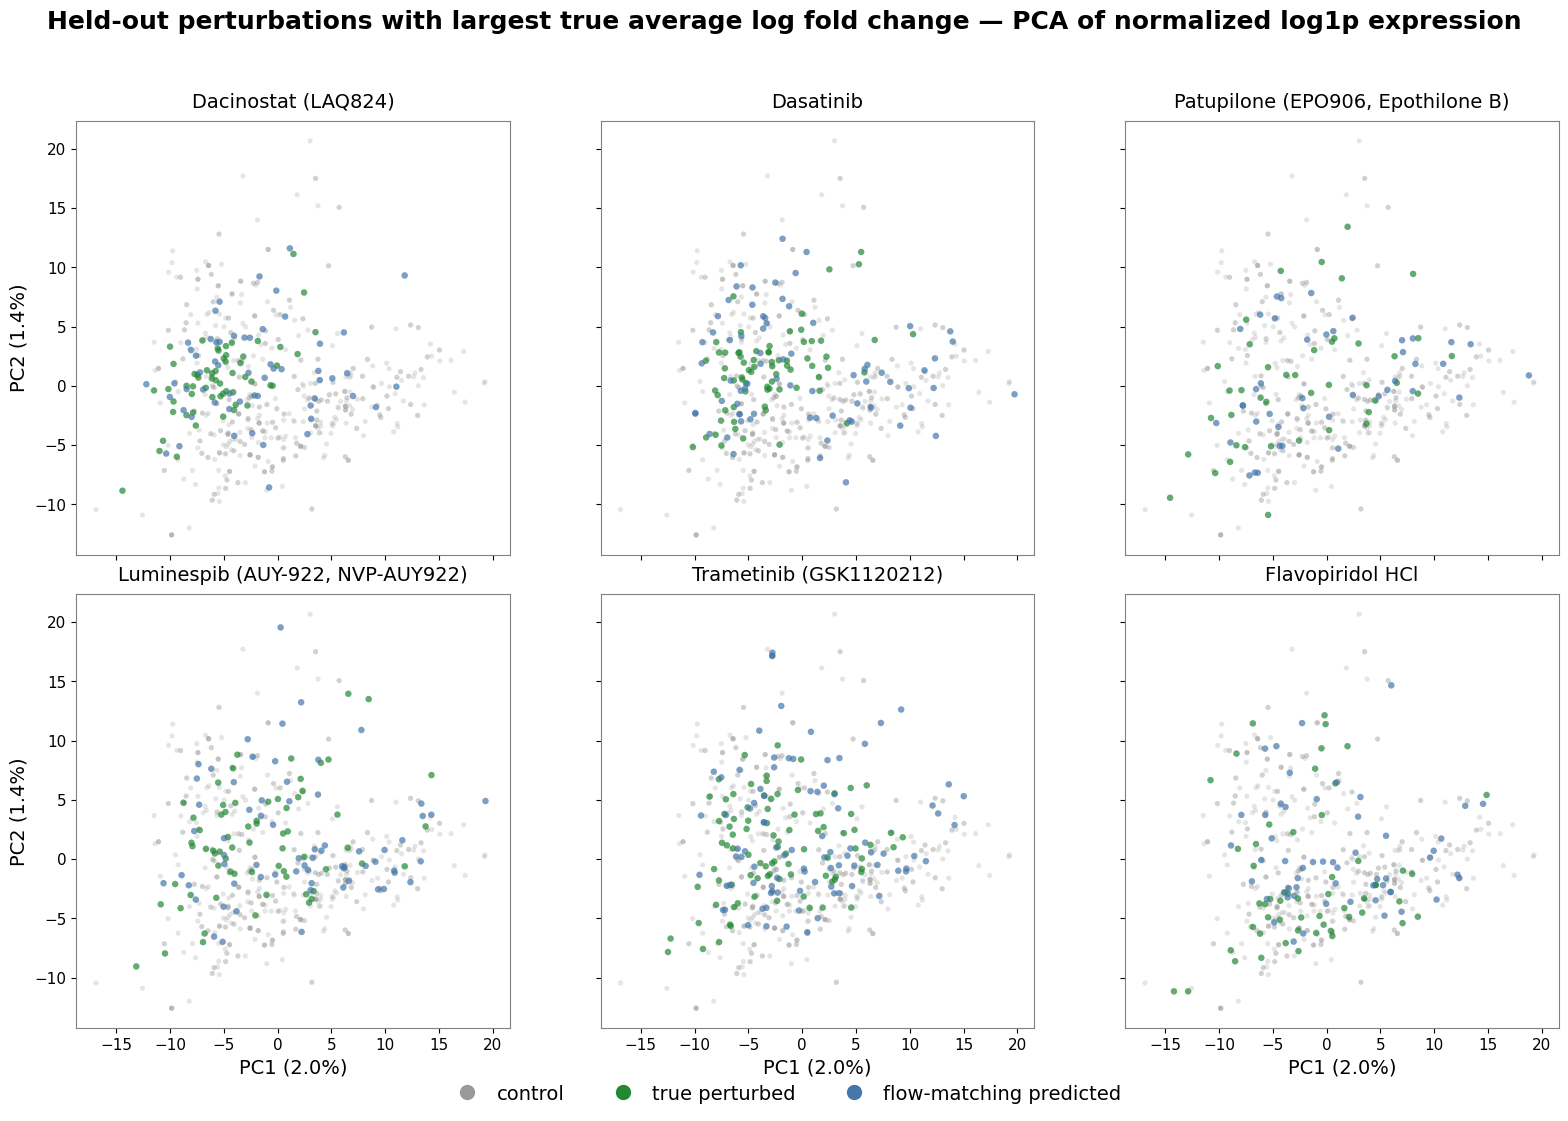

In [15]:
from sklearn.decomposition import PCA
from matplotlib.lines import Line2D

FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)
plt.rcParams["mathtext.fontset"] = "cm"

# get held-out views in base space (cached from previous cell)
held_out_views = prepare_metric_space_views(
    datamodule=bundle.datamodule,
    raw_adata=bundle.datamodule.adata_full,
    predictions=predictions,
    metric_space=base_metric_space,
    comparison_pipeline=bundle.comparison_pipeline,
    comparison_space_cfg=bundle.comparison_space_cfg,
    cache=bundle.cache,
)

ho_pred_X = np.asarray(held_out_views.prediction_adata.X, dtype=np.float64)
ho_ref_X = np.asarray(held_out_views.reference_adata.X, dtype=np.float64)
ho_ctrl_X = np.asarray(held_out_views.control_adata.X, dtype=np.float64)
ho_obs = held_out_views.obs

ho_ctrl_mean = ho_ctrl_X.mean(axis=0)

# rank perturbation groups by mean |true logfc|
pert_stats = []
for grp_key, frame in ho_obs.groupby(list(group_columns)):
    if not isinstance(grp_key, tuple):
        grp_key = (grp_key,)
    if str(grp_key[-1]) == control_value:
        continue
    idx = frame.index.to_numpy()
    pred_lfc = ho_pred_X[idx].mean(axis=0) - ho_ctrl_mean
    true_lfc = ho_ref_X[idx].mean(axis=0) - ho_ctrl_mean
    pert_stats.append(
        {
            "group_key": grp_key,
            "mean_abs_pred_lfc": float(np.abs(pred_lfc).mean()),
            "mean_abs_true_lfc": float(np.abs(true_lfc).mean()),
            "indices": idx,
            "label": str(grp_key[-1]),
        }
    )

pert_df = pd.DataFrame(pert_stats).sort_values("mean_abs_true_lfc", ascending=False)
top_perts = pert_df.head(6)
print(top_perts[["label", "mean_abs_pred_lfc", "mean_abs_true_lfc"]].to_string(index=False))

# fit PCA on control cells
pca_2d = PCA(n_components=2)
pca_2d.fit(ho_ctrl_X)

ctrl_pca = pca_2d.transform(ho_ctrl_X)
ref_pca = pca_2d.transform(ho_ref_X)
pred_pca = pca_2d.transform(ho_pred_X)

rng = np.random.default_rng(42)
ctrl_sample_idx = rng.choice(ctrl_pca.shape[0], size=min(500, ctrl_pca.shape[0]), replace=False)

CTRL_COLOR = "#999999"
TRUE_COLOR = "#228833"
PRED_COLOR = "#4477AA"

n_plots = len(top_perts)
n_cols = 3
n_rows = max(1, (n_plots + n_cols - 1) // n_cols)
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5.5 * n_cols, 5.5 * n_rows),
    sharex=True,
    sharey=True,
)
axes = np.atleast_2d(axes)

for i, (_, row) in enumerate(top_perts.iterrows()):
    ax = axes[i // n_cols, i % n_cols]
    idx = row["indices"]

    ax.scatter(
        ctrl_pca[ctrl_sample_idx, 0],
        ctrl_pca[ctrl_sample_idx, 1],
        alpha=0.25,
        s=14,
        color=CTRL_COLOR,
        edgecolors="none",
        rasterized=True,
    )
    ax.scatter(
        ref_pca[idx, 0],
        ref_pca[idx, 1],
        alpha=0.7,
        s=22,
        color=TRUE_COLOR,
        edgecolors="none",
        rasterized=True,
    )
    ax.scatter(
        pred_pca[idx, 0],
        pred_pca[idx, 1],
        alpha=0.7,
        s=22,
        color=PRED_COLOR,
        edgecolors="none",
        rasterized=True,
    )

    ax.set_title(
        f"{row['label']}",
        fontsize=14,
        pad=10,
    )
    ax.set_box_aspect(1)
    ax.tick_params(labelsize=11)
    for spine in ax.spines.values():
        spine.set_color("0.5")
        spine.set_linewidth(0.8)

# axis labels only on edges
for c in range(n_cols):
    axes[n_rows - 1, c].set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})", fontsize=14)
for r in range(n_rows):
    axes[r, 0].set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})", fontsize=14)

for j in range(n_plots, n_rows * n_cols):
    axes[j // n_cols, j % n_cols].set_visible(False)

legend_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="",
        markerfacecolor=CTRL_COLOR,
        markeredgecolor="none",
        markersize=11,
        label="control",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="",
        markerfacecolor=TRUE_COLOR,
        markeredgecolor="none",
        markersize=11,
        label="true perturbed",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="",
        markerfacecolor=PRED_COLOR,
        markeredgecolor="none",
        markersize=11,
        label="flow-matching predicted",
    ),
]
fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=3,
    bbox_to_anchor=(0.5, -0.01),
    fontsize=14,
    frameon=False,
    handletextpad=0.5,
    columnspacing=2.0,
)

fig.suptitle(
    "Held-out perturbations with largest true average log fold change — PCA of normalized log1p expression",
    fontsize=18,
    fontweight="bold",
    y=1.0,
)
fig.tight_layout(rect=[0, 0.02, 1, 0.97])
fig.savefig(
    FIGURES_DIR / "view_flow_results_held_out_perturbations_pca.svg",
    bbox_inches="tight",
    dpi=200,
)
plt.show()

In [14]:
# latent space dispersion diagnostic
# compare FM predicted latents vs true encoded latents for top perturbations
# to determine if underdispersion originates in latent space or decoding

from flatcfm.data.space import AELatentProjection

ae_proj = None
for proj in bundle.datamodule.train_pipeline.projections:
    if isinstance(proj, AELatentProjection):
        ae_proj = proj
        break

if ae_proj is None:
    print("no AE projection found — skipping latent diagnostic")
else:
    import torch as _torch

    ae_model = ae_proj.ae_model
    ae_model.eval()
    _device = next(ae_model.parameters()).device

    # encode held-out predictions and true perturbed to latent space
    ho_pred_base = np.asarray(held_out_views.prediction_adata.X, dtype=np.float32)
    ho_ref_base = np.asarray(held_out_views.reference_adata.X, dtype=np.float32)
    ho_ctrl_base = np.asarray(held_out_views.control_adata.X, dtype=np.float32)

    with _torch.no_grad():
        z_pred = ae_model.encode(_torch.as_tensor(ho_pred_base, device=_device)).cpu().numpy()
        z_ref = ae_model.encode(_torch.as_tensor(ho_ref_base, device=_device)).cpu().numpy()
        z_ctrl = ae_model.encode(_torch.as_tensor(ho_ctrl_base, device=_device)).cpu().numpy()

    # per-dimension variance comparison
    var_pred = z_pred.var(axis=0)
    var_ref = z_ref.var(axis=0)
    var_ctrl = z_ctrl.var(axis=0)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # overall variance per latent dim
    dims = np.arange(len(var_pred))
    axes[0].bar(dims, var_ref, alpha=0.5, color="#228833", label="true perturbed")
    axes[0].bar(dims, var_pred, alpha=0.5, color="#4477AA", label="FM predicted")
    axes[0].bar(dims, var_ctrl, alpha=0.3, color="#999999", label="control")
    axes[0].set_xlabel("latent dimension")
    axes[0].set_ylabel("variance")
    axes[0].set_title("per-dimension latent variance (all held-out cells)")
    axes[0].legend(fontsize=8)
    axes[0].grid(alpha=0.2)

    # scatter: pred variance vs ref variance per dim
    axes[1].scatter(var_ref, var_pred, s=15, alpha=0.5, color="#4477AA")
    lim = max(var_ref.max(), var_pred.max()) * 1.05
    axes[1].plot([0, lim], [0, lim], "k--", alpha=0.3)
    axes[1].set_xlabel("true perturbed variance")
    axes[1].set_ylabel("FM predicted variance")
    axes[1].set_title(
        f"latent variance per dim\nratio median={np.median(var_pred / np.clip(var_ref, 1e-10, None)):.3f}"
    )
    axes[1].set_aspect("equal")
    axes[1].grid(alpha=0.2)

    # per-perturbation: compare total latent norm spread
    pert_dispersion = []
    for grp_key, frame in ho_obs.groupby(list(group_columns)):
        if not isinstance(grp_key, tuple):
            grp_key = (grp_key,)
        if str(grp_key[-1]) == control_value:
            continue
        idx = frame.index.to_numpy()
        if len(idx) < 3:
            continue
        pred_std = float(np.linalg.norm(z_pred[idx] - z_pred[idx].mean(axis=0), axis=1).std())
        ref_std = float(np.linalg.norm(z_ref[idx] - z_ref[idx].mean(axis=0), axis=1).std())
        pert_dispersion.append({"label": str(grp_key[-1]), "pred_std": pred_std, "ref_std": ref_std})

    disp_df = pd.DataFrame(pert_dispersion)
    if not disp_df.empty:
        axes[2].scatter(disp_df["ref_std"], disp_df["pred_std"], s=15, alpha=0.5, color="#4477AA")
        lim2 = max(disp_df["ref_std"].max(), disp_df["pred_std"].max()) * 1.05
        axes[2].plot([0, lim2], [0, lim2], "k--", alpha=0.3)
        axes[2].set_xlabel("true perturbed spread (std of L2 norms)")
        axes[2].set_ylabel("FM predicted spread")
        ratio = (disp_df["pred_std"] / disp_df["ref_std"].clip(lower=1e-10)).median()
        axes[2].set_title(f"per-perturbation latent spread\nmedian ratio={ratio:.3f}")
        axes[2].set_aspect("equal")
        axes[2].grid(alpha=0.2)

    plt.suptitle("latent space dispersion: FM predicted vs true encoded", y=1.02)
    plt.tight_layout()
    plt.show()

    print(f"total variance — ctrl: {var_ctrl.sum():.2f}  ref: {var_ref.sum():.2f}  pred: {var_pred.sum():.2f}")
    print(
        f"variance ratio (pred/ref) — mean: {(var_pred / np.clip(var_ref, 1e-10, None)).mean():.3f}  median: {np.median(var_pred / np.clip(var_ref, 1e-10, None)):.3f}"
    )

no AE projection found — skipping latent diagnostic
